In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.lines import Line2D
%matplotlib inline

# Import the custom package we designed
from pop3_cmb.cosmology import CAMBRunner
from pop3_cmb.faraday import FaradayModel
from pop3_cmb.spectrum import VVSpectrum
from pop3_cmb.config import CONSTANTS, COSMOLOGY, PARAMS

# Plotting settings for publication-quality figures
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


Step 1 - Cosmology & E-mode Power Spectrum $P_E​(k,\eta)$

First, we compute the background cosmology and the source of polarization: the linear matter power spectrum $P_{\rm lin}(k)$ and the primordial E-modes.

Educational Note: The E-mode power spectrum $P_E​(k,\eta)$ tells us how much polarization signal exists at a given scale $k$ and conformal time $\eta$ (or redshift $z$). This acts as the "background light" that gets converted into V-modes by the Pop III "screen".

Running CAMB to get background cosmology...
Note: redshifts have been re-sorted (earliest first)
CAMB run complete in 21.75s


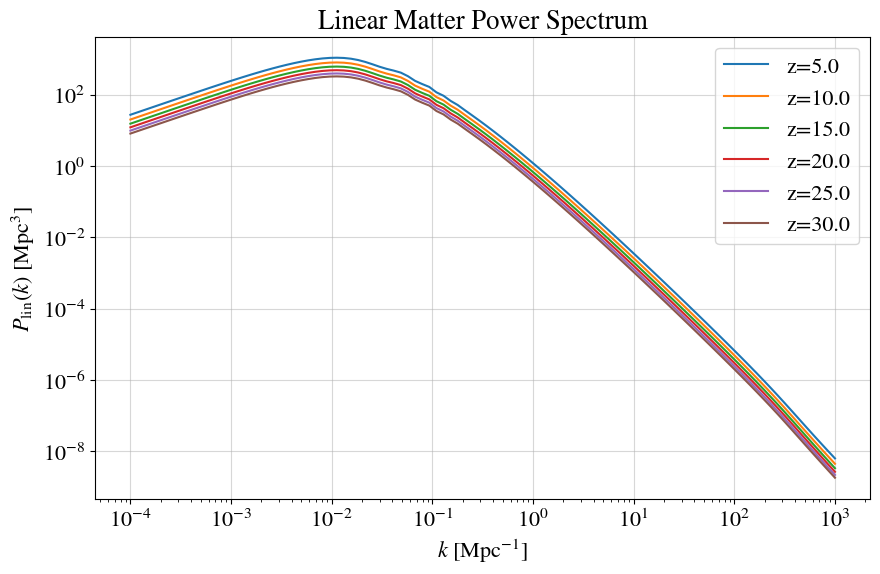

In [ ]:
# Setup Parameters for a "Fast" Run (Low Resolution)
# We reduce resolution to make this notebook run quickly for demonstration.
test_params = PARAMS.copy()
test_params.update({
    'n_k_points': 100,         # Fewer k points for speed
    'n_M_points': 20,          # Coarser mass grid
    'z_min': 5,
    'z_max': 30,               # Focusing on Reionization era
    'k_min': 1e-4, 
    'k_max': 1e3,              # High k needed for small halos
})

# Initialize CAMB Interface
print("Running CAMB to get background cosmology...")
t0 = time.time()

camb_run = CAMBRunner(
    COSMOLOGY, 
    k_min=test_params['k_min'], 
    k_max=test_params['k_max'], 
    n_k_points=test_params['n_k_points'],
    z_min=test_params['z_min'], 
    z_max=test_params['z_max']
)

# Get Linear Matter Power Spectrum P_lin(k, z)
# This drives structure formation (halos).
z_grid, k_grid, Plin = camb_run.get_linear_matter_power()
r_grid = camb_run.get_comoving_distance(z_grid)

print(f"CAMB run complete in {time.time()-t0:.2f}s")

# --- VISUALIZATION: Matter Power Spectrum ---
plt.figure()
for i, z in enumerate(z_grid[::5]): # Plot every 5th redshift
    plt.loglog(k_grid, Plin[i], label=f'z={z}')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{\rm lin}(k)$ [Mpc$^3$]')
plt.title("Linear Matter Power Spectrum")
plt.legend()
plt.grid(True, alpha=0.5)

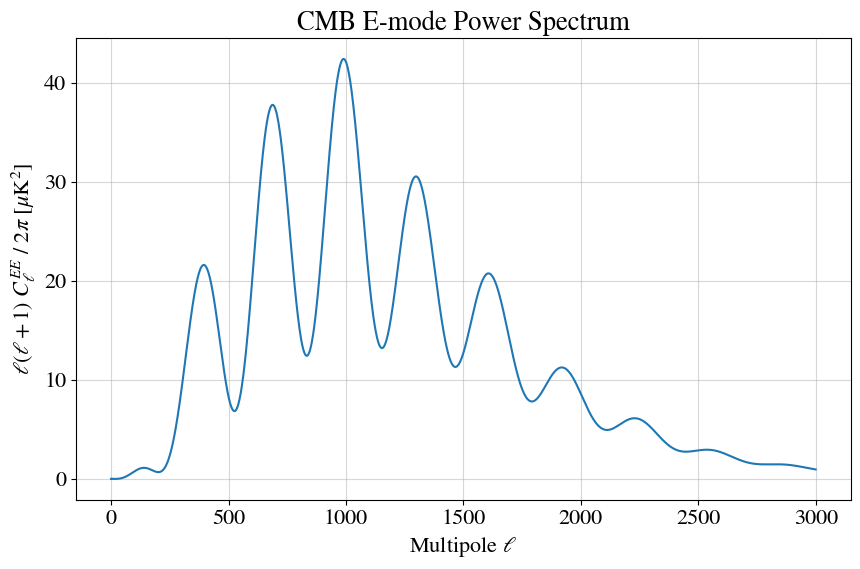

In [ ]:
# Get Primordial Angular E-mode Spectrum C_l^EE
# We need this for the final convolution.
lmax_cmb = 3000
ls_ee, Cl_EE = camb_run.get_primordial_Cl_EE(lmax=lmax_cmb)

# --- VISUALIZATION: Primordial E-mode Spectrum ---
plt.figure()
plt.plot(ls_ee, ls_ee*(ls_ee+1)/(2*np.pi) * Cl_EE)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1) \ C_\ell^{EE} \ / \ 2\pi \ [\mu \rm{K}^2]$')

plt.title("CMB E-mode Power Spectrum")
plt.grid(True, alpha=0.5)

Step 2 - 3D Faraday Conversion Power Spectrum ($P_\alpha$​)

This is the core physics of the Pop III stars. The conversion rate $\alpha$ depends on the magnetic fields and relativistic electrons in supernova remnants.

- 1-Halo Term ($P^{1h}$): correlations of supernovae within a single halo (shot noise).
$$
P_\alpha^\mathrm{1h}(k) = \int dM \, \frac{dn}{dM} \, \alpha_\mathrm{single}^2(M) \, u_\mathrm{SN}^2(k)
    \left[
      N_\mathrm{SN} + N_\mathrm{SN}\left(N_\mathrm{SN}-1\right) \, u^2_\mathrm{halo}(k)
    \right].
$$
- 2-Halo Term ($P^{2h}$): correlations between different halos (traces large-scale structure).
$$
P_\alpha^\mathrm{2h}(k)
  = \left[
      \int dM\; \frac{dn}{dM} \; b(M) \; 
        \alpha_\mathrm{single}(M) \; N_\mathrm{SN} \; u_\mathrm{SN}(k)
    \right]^2
    P_\mathrm{lin}(k).
$$
Where:
- $dn/dM$: Halo mass function.
- $\alpha_\mathrm{single}(M)$: Faraday conversion rate for a single supernova in a halo of mass $M$.
- $N_\mathrm{SN}$: Number of supernovae in the halo.
- $u_\mathrm{SN}(k)$: Fourier transform of the supernova spatial profile.
- $u_\mathrm{halo}(k)$: Fourier transform of the halo density profile.
- $b(M)$: Halo bias.
The total 3D Faraday conversion power spectrum is then:
$$
P_\alpha(k) = P_\alpha^\mathrm{1h}(k) + P_\alpha^\mathrm{2h}(k).
$$

In [4]:
print("Computing Faraday Conversion Power Spectrum P_alpha(k)...")
t0 = time.time()

# Initialize the Faraday Model with our cosmology and parameters
fm = FaradayModel(camb_run, test_params, CONSTANTS, k_grid, Plin)

# P_alpha_total = fm.compute_P_alpha(return_components=False)
P1h, P2h = fm.compute_P_alpha(return_components=True)
P_alpha_total = P1h + P2h

print(f"Faraday calculation done in {time.time()-t0:.2f}s")

Computing Faraday Conversion Power Spectrum P_alpha(k)...
Faraday calculation done in 0.31s


Visualization - Plotting the $P_\alpha​(k)$

Here we generate the plot showing the 1-halo (flat at low $k$) and 2-halo (follows matter spectrum) terms for various redshifts.

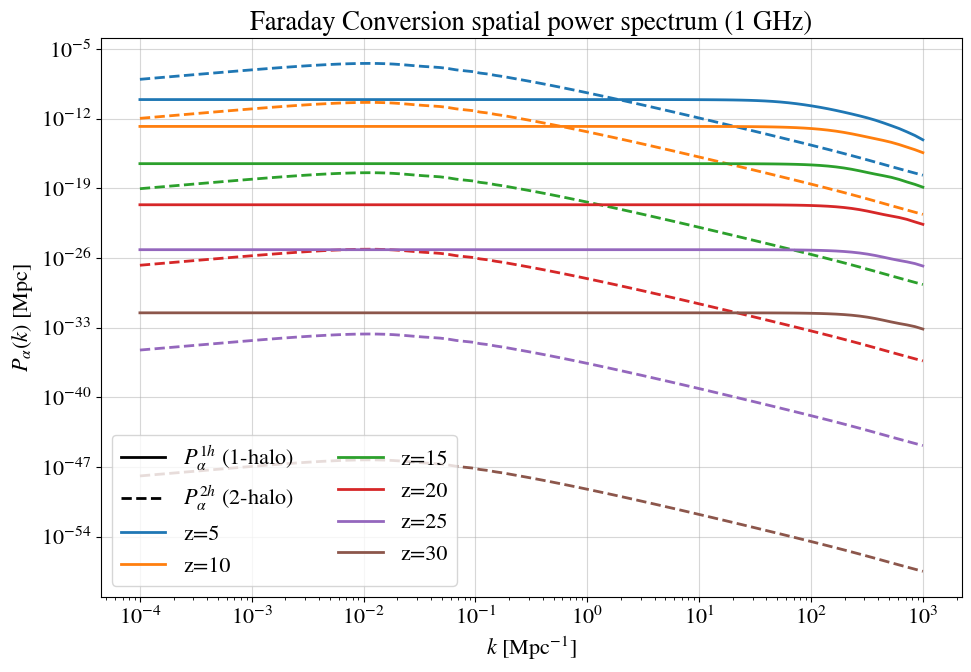

In [ ]:
redshifts_to_plot = np.arange(fm.z_arr[0], fm.z_arr[-1] + 1, 5) # [5, 10, 15, 20, 25, 30]
# colors = plt.cm.tab10(np.linspace(0, 1, len(redshifts_to_plot)))
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

fig, ax = plt.subplots(figsize=(10, 7))

# Dummy lines for legend
legend_lines = [
    Line2D([0], [0], color='k', linestyle='-', lw=2, label=r'$P_{\alpha}^{1h}$ (1-halo)'),
    Line2D([0], [0], color='k', linestyle='--', lw=2, label=r'$P_{\alpha}^{2h}$ (2-halo)')
]

for idx, z_target in enumerate(redshifts_to_plot):
    # Find nearest index in z_grid
    z_idx = np.argmin(np.abs(z_grid - z_target))
    
    # Plot 1-halo (Solid)
    ax.loglog(k_grid, P1h[z_idx], color=colors[idx], linestyle='-', lw=2)
    
    # Plot 2-halo (Dashed)
    ax.loglog(k_grid, P2h[z_idx], color=colors[idx], linestyle='--', lw=2, alpha=1)
    
    # Add color legend entry
    legend_lines.append(Line2D([0], [0], color=colors[idx], lw=2, label=f'z={z_target}'))

ax.set_xlabel(r'$k$ [Mpc$^{-1}$]')
ax.set_ylabel(r'$P_\alpha(k)$ [Mpc]') # Units depend on alpha definition
ax.set_title(f'Faraday Conversion spatial power spectrum ({int(PARAMS['nu_Hz']*1e-9)} GHz)')
ax.legend(handles=legend_lines, ncol=2, fontsize=16)
ax.grid(True, which='major', alpha=0.5)

plt.tight_layout()
# plt.savefig('./figures/P_alpha_components.pdf', )

Step 3 - 2D Angular Faraday Spectrum $C_\ell^\alpha​$

Now we project the 3D structure onto the sky. We use the Limber Approximation:
$$
C_{\ell}^\alpha = \int dr\, r^2\, P_{\alpha}\left(k = \frac{\ell}{r},\, z(r)\right)
$$

This tells us the statistical distribution of "Faraday conversion screens" on the sky.

Computing Angular Faraday Spectrum C_l^alpha...
Limber integration done in 0.10s


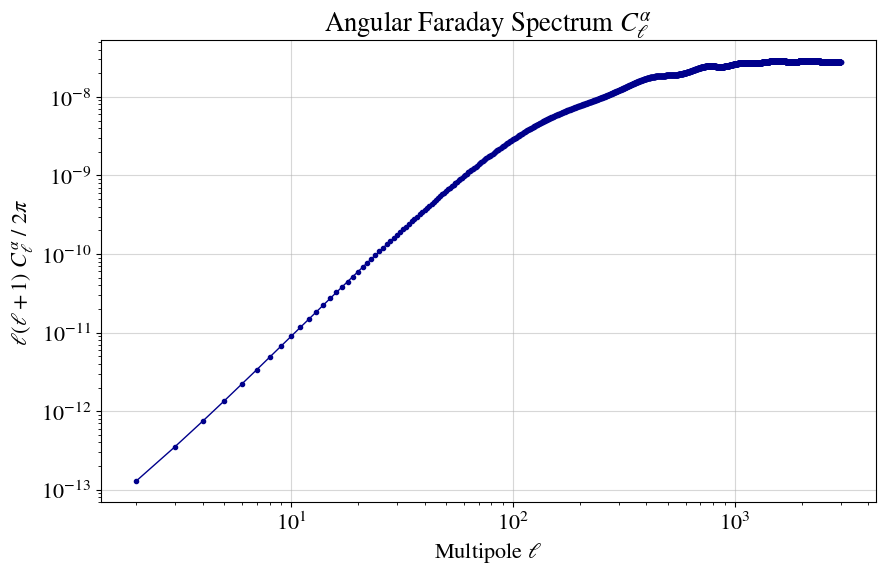

In [ ]:
print("Computing Angular Faraday Spectrum C_l^alpha...")
t0 = time.time()

# Define ell range for computation
ell_min, ell_max = 2, lmax_cmb
l_values = np.arange(ell_min, ell_max)

# Initialize Spectrum Calculator
convolution = VVSpectrum(ell_min, ell_max, P_alpha_total, z_grid, r_grid, k_grid, Cl_EE)

# Perform Limber Integration
Cl_alpha = convolution.compute_Cl_alpha_limber(l_values) # dimensionless

print(f"Limber integration done in {time.time()-t0:.2f}s")

# --- VISUALIZATION ---
plt.figure()
plt.loglog(l_values, l_values*(l_values+1)*Cl_alpha/(2*np.pi), marker='.', lw=1, color='darkblue')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1) \ C_\ell^\alpha \ / \ 2\pi$')
plt.title(r'Angular Faraday Spectrum $C_\ell^\alpha$')
plt.grid(True, which='major', alpha=0.5)
# plt.savefig('./figures/Cl_alpha.pdf', )

Step 4 - Circular Polarization Spectrum $C_\ell^{VV}$

The V-mode power spectrum is the convolution of the Faraday conversion rate angular power spectrum ($C_\ell^\alpha$​) and the primordial E-mode spectrum ($C_{\ell}^{EE}$​):
$$
C_{\ell}^{V V}=\sum_{L, \ell^{\prime}} C_L^\alpha C_{\ell^{\prime}}^{E E} \frac{(2 L+1)\left(2 \ell^{\prime}+1\right)}{4 \pi}\left(\begin{array}{ccc}
\ell & L & \ell^{\prime} \\
2 & 0 & -2
\end{array}\right)^2
$$
Where 
$$
\left(\begin{array}{ccc}
\ell & L & \ell^{\prime} \\
2 & 0 & -2
\end{array}\right)
$$ 
is the Wigner-3j symbol.

This mixing generates V-modes from pure E-modes.

In [ ]:
try:
    ls_vv, Cl_VV = np.loadtxt('./Cl_VV.txt', unpack=True)
except Exception as e:
    print(f"Error loading Cl_VV data: {e}")
    ls_vv, Cl_VV = convolution.compute_Cl_VV()
    # np.savetxt('./Cl_alpha.txt', np.column_stack((l_values, Cl_alpha)), header='ell Cl_alpha')
    np.savetxt('./Cl_VV.txt', np.column_stack((ls_vv, Cl_VV)), header='ell Cl_VV')

Computing Cl_VV (Convolution)...
  Processed ell=2
  Processed ell=3
  Processed ell=4
  Processed ell=6
  Processed ell=9
  Processed ell=12
  Processed ell=16
  Processed ell=22
  Processed ell=31
  Processed ell=42
  Processed ell=57
  Processed ell=77
  Processed ell=105
  Processed ell=142
  Processed ell=193
  Processed ell=262
  Processed ell=355
  Processed ell=482
  Processed ell=653
  Processed ell=886
  Processed ell=1202
  Processed ell=1630
  Processed ell=2211
  Processed ell=3000
Convolution done in 25m 31.18s


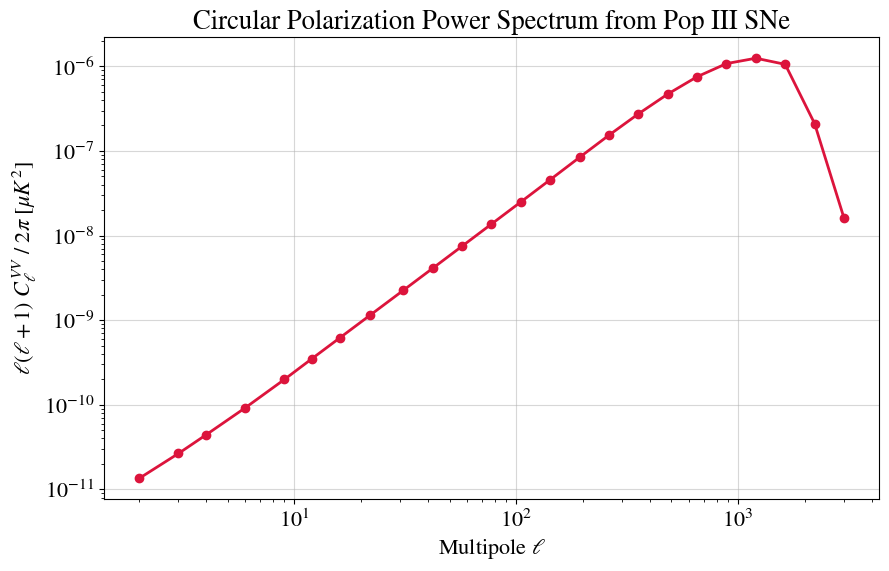

In [ ]:
# plt.figure(figsize=(10, 6))
plt.plot(ls_vv, ls_vv*(ls_vv+1)*Cl_VV/(2*np.pi), 'o-', color='crimson', lw=2,) #label=r'Pop III Signal'
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)\ C_\ell^{VV}\ /\ 2\pi$ [$\mu K^2$]')
plt.title(r'Circular Polarization Power Spectrum from Pop III SNe')
plt.grid(True, which='major', alpha=0.5)
# plt.savefig('./figures/Cl_VV.pdf', )